L'obiettivo del progetto è sviluppare un modello di machine learning basato su tecniche di Natural Language Processing (NLP) per identificare la lingua di testi forniti dal museo. 

Questo modello dovrà:

- Riconoscere automaticamente la lingua di un testo.
- Supportare almeno 3 lingue principali.
- Essere facile da integrare con il sistema esistente del museo.

Il progetto è stato sviluppato seguendo un approccio strutturato che ha previsto l’analisi del problema, la raccolta e la preparazione dei dati, e la sperimentazione di diverse soluzioni per il riconoscimento dei test museali. 
Sono state implementate e confrontate varie strategie per migliorare l’accuratezza e l’affidabilità del sistema. 

I risultati ottenuti evidenziano un incremento significativo nella capacità di identificazione e classificazione, ponendo le basi per applicazioni pratiche e ulteriori sviluppi.

In [52]:
import pandas as pd
import numpy as np
import string
import re
import spacy
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [53]:
def my_ngram_function(sentence, n):
  """
  Funzione che restituisce gli n-gram di una frase.

  input: una stringa e un intero (ngrams)
  output: una lista di stringhe
  """
  return ["".join(ngr) for ngr in ngrams(sentence, n)]

def data_cleaner(dataset):
  """
  La funzione restituisce una frase pulita con rimozione dei caratteri speciali, rimozione dei numeri, rimozione di spazi multipli.
  Non vengono rimosse le stopwords in quanto si ritiene che per il problema affrontato, rappresentino un importante caratteristica per il riconoscimento della lingua della frate.

  input: una lista di stringhe
  output: una lista di stringhe pulite
  """
  cleaned = []
  for sentence in dataset:
      sentence = sentence.lower()
      sentence = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", sentence)
      sentence = re.sub(r"\d+", " ", sentence)
      sentence = re.sub(r"\s+", " ", sentence).strip()
      cleaned.append(sentence)
  return cleaned

def bow_count(dataset, count_vectorizer=None):
  """
  Funzione per la creazione del Bag-of-words.
  Non viene utilizzato un approccio tf-idf poichè il dataset utilizzato si presenta come omogeneo.
  l'approccio tf-idf si basa tanto sulla eterogenità del dataset, per questo risulta poco appropriato per il problema corrente.

  input: una lista di stringhe
  output: una matrice di conteggi e il count vectorizer
  """
  if count_vectorizer is None:
      count_vectorizer = CountVectorizer()
      X = count_vectorizer.fit_transform(dataset)
  else:
      X = count_vectorizer.transform(dataset)
  return X.toarray(), count_vectorizer


In [54]:
RANDOM_SEED = 42
DATASET_URL = "https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv"

### **Caricamento del dataset**

In [55]:
df = pd.read_csv(DATASET_URL)
print(df.head())
print("----------------------------------------------------------")
print(f"Il dataset ha {df.shape[0]} righe e {df.shape[1]} colonne")

                                               Testo Codice Lingua
0  Statua in marmo di un imperatore romano del II...            it
1         Anfora greca con decorazioni a figure nere            it
2  Dipinto rinascimentale raffigurante la Madonna...            it
3         Elmo corinzio in bronzo del VI secolo a.C.            it
4         Manoscritto medievale con miniature dorate            it
----------------------------------------------------------
Il dataset ha 294 righe e 2 colonne


Verifico se all'interno del dataset sono presenti dei valori NaN

In [56]:
nan_values = df.isna().sum()
print("\nVerifica valori mancanti:\n", nan_values if nan_values.any() else "Nessun valore mancante")


Verifica valori mancanti:
 Nessun valore mancante


Verifico se il dataset è bilanciato e quali lingue sono presenti al suo interno

In [57]:
languages = df['Codice Lingua'].unique()
print(f"\nLingue presenti: {languages}")
for l in languages:
    print(f"{l}: {len(df[df['Codice Lingua'] == l])} esempi")


Lingue presenti: ['it' 'en' 'de']
it: 98 esempi
en: 98 esempi
de: 98 esempi


Creazione dei dataset di training e di testing

In [58]:
target = df['Codice Lingua']
X_train, X_test, y_train, y_test = train_test_split(
    df['Testo'],
    df['Codice Lingua'],
    test_size=0.2,
    random_state=RANDOM_SEED
)

# Pulizia delle frasi
X_train_clean = data_cleaner(X_train)
X_test_clean = data_cleaner(X_test)

# Creazinoe degli ngrammi
X_ngr_train = [" ".join(my_ngram_function(s, 2)) for s in X_train_clean]
X_ngr_test = [" ".join(my_ngram_function(s, 2)) for s in X_test_clean]

# Bag of words
X_train_bow, cvectorizer = bow_count(X_ngr_train, None)
X_test_bow, _ = bow_count(X_ngr_test, cvectorizer)

Addestramento di 4 diversi modelli di Machine Learning e selezione del miglior modello considerando la miglior accuracy ottenuta nel training.

In [59]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=RANDOM_SEED)
}

results = {}

# Addestramento
for name, clf in models.items():
    clf.fit(X_train_bow, y_train)
    y_pred = clf.predict(X_test_bow)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


--- Naive Bayes ---
Accuracy: 0.9491525423728814
              precision    recall  f1-score   support

          de       0.95      1.00      0.98        20
          en       0.94      0.88      0.91        17
          it       0.95      0.95      0.95        22

    accuracy                           0.95        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.95      0.95      0.95        59


--- Linear SVM ---
Accuracy: 0.9322033898305084
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        20
          en       0.93      0.82      0.88        17
          it       0.88      0.95      0.91        22

    accuracy                           0.93        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.93      0.93      0.93        59


--- Random Forest ---
Accuracy: 0.9322033898305084
              precision    recall  f1-score   support

          de       1.00      1.0

In [60]:
# Identificazione del miglior modello
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"Modello migliore: {best_model_name} (Accuracy = {results[best_model_name]:.3f})")

Modello migliore: Logistic Regression (Accuracy = 0.966)



--- Valutazione finale del modello selezionato ---
Classification Report:
               precision    recall  f1-score   support

          de       1.00      1.00      1.00        20
          en       1.00      0.88      0.94        17
          it       0.92      1.00      0.96        22

    accuracy                           0.97        59
   macro avg       0.97      0.96      0.96        59
weighted avg       0.97      0.97      0.97        59

Accuracy: 0.9661016949152542

Matrice di Confusione:
 [[20  0  0]
 [ 0 15  2]
 [ 0  0 22]]




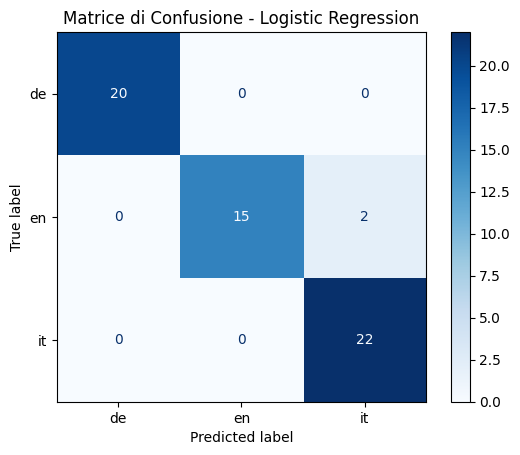

In [61]:
# Riaddestramento del modello migliore
best_model.fit(X_train_bow, y_train)
y_pred_best = best_model.predict(X_test_bow)

# Metriche finali dettagliate
print("\n--- Valutazione finale del modello selezionato ---")
print("Classification Report:\n", classification_report(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nMatrice di Confusione:\n", cm)
print("\n")
# Visualizzazione grafica della matrice di confusione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matrice di Confusione - {best_model_name}")
plt.show()

(Non richiesto per il progetto).

 Addestramento di un MLPClassifier molto semplice, per valutarne l'accuratezza rispetto al miglior modello selezionato in precedenza


In [62]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    activation='logistic', solver='adam', max_iter=200,
    hidden_layer_sizes=(100,), tol=0.05, verbose=False, random_state=RANDOM_SEED
)
mlp.fit(X_train_bow, y_train)
y_pred = mlp.predict(X_test_bow)
print("\n--- MLP Classifier (opzionale) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))


if results[best_model_name] < accuracy_score(y_test, y_pred):
  print(f"\nMLPClassifier mostra una miglior performance rispetto al {best_model_name}")
else:
  print(f"\nMLPClassifier non risulta essere migliore di {best_model_name}")



--- MLP Classifier (opzionale) ---
Accuracy: 0.9152542372881356

MLPClassifier non risulta essere migliore di Logistic Regression
